In [ ]:
# Install necessary libraries
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os
import shutil
from google.colab import drive

print("✅ Environment Libraries Installed and Ready.")

✅ Environment Libraries Installed and Ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your folder
# NOTE: Ensure you created a folder named 'SDWAN_Project' in your Drive
folder_path = '/content/drive/My Drive/SDWAN_Project'

# Check if the folder exists
if os.path.exists(folder_path):
    print(f"✅ Connected to your folder: {folder_path}")
else:
    print("❌ Error: Folder 'SDWAN_Project' not found in My Drive.")
    print("Please go to Google Drive, create the folder, and upload the CSV there.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Connected to your folder: /content/drive/My Drive/SDWAN_Project


In [ ]:
# Define filename
csv_filename = 'Dataset-Unicauca-Version2-87Atts.csv'
file_path = os.path.join(folder_path, csv_filename)

print("⏳ Loading dataset...")

try:
    # 1. Read slightly more data (250k rows)
    df = pd.read_csv(file_path, nrows=400000)

    # 2. SHUFFLE THE DATA (Crucial for higher accuracy!)
    # This ensures we get a mix of all apps, not just the first ones in the file
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"✅ Dataset Loaded & Shuffled. Shape: {df.shape}")

    # --- CLEANING ---
    if 'ProtocolName' in df.columns:
        target_col = 'ProtocolName'
    elif 'L7Protocol' in df.columns:
        target_col = 'L7Protocol'
    else:
        target_col = df.columns[-1]

    # Standard Features
    features_to_keep = [
        'Source.Port', 'Destination.Port', 'Protocol', 'Flow.Duration',
        'Total.Fwd.Packets', 'Total.Backward.Packets', 'Total.Length.of.Fwd.Packets',
        'Total.Length.of.Bwd.Packets', 'Fwd.Packet.Length.Max', 'Fwd.Packet.Length.Mean',
        'Bwd.Packet.Length.Max', 'Bwd.Packet.Length.Mean', target_col
    ]

    available_cols = df.columns.intersection(features_to_keep)
    df_clean = df[available_cols].dropna()

    print(f"✅ Data Cleaned. Rows ready: {len(df_clean)}")

except FileNotFoundError:
    print(f"❌ Error: File '{csv_filename}' not found.")

⏳ Loading dataset...
✅ Dataset Loaded & Shuffled. Shape: (400000, 87)
✅ Data Cleaned. Rows ready: 400000


/tmp/ipython-input-914219961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_apps.index, x=top_apps.values, palette='viridis')


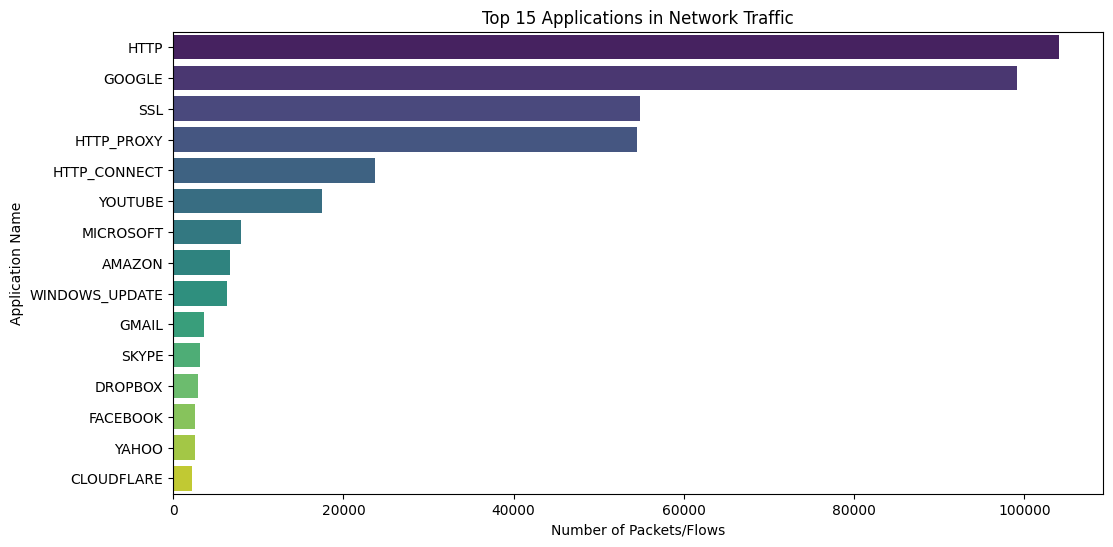

Observation: If the top bar is huge, the model might be biased toward that app.


In [ ]:
# Cell: EDA - Top 15 Apps Distribution
plt.figure(figsize=(12, 6))

# Count the top 15 most frequent apps
top_apps = df_clean[target_col].value_counts().head(15)

# Create Bar Plot
sns.barplot(y=top_apps.index, x=top_apps.values, palette='viridis')
plt.title('Top 15 Applications in Network Traffic')
plt.xlabel('Number of Packets/Flows')
plt.ylabel('Application Name')
plt.show()

print("Observation: If the top bar is huge, the model might be biased toward that app.")

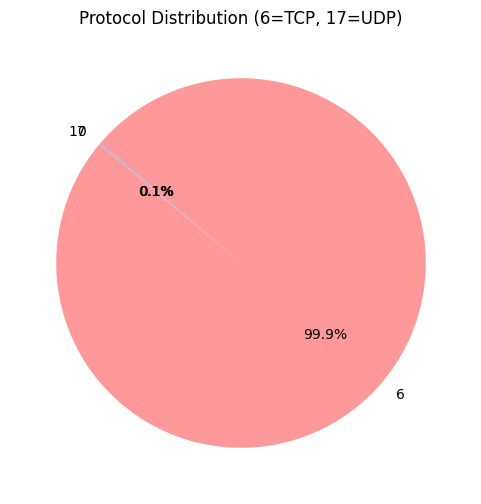

In [ ]:
# Cell: EDA - Protocol Distribution (TCP vs UDP)
plt.figure(figsize=(6, 6))

# 6 = TCP, 17 = UDP
protocol_counts = df_clean['Protocol'].value_counts()
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Protocol Distribution (6=TCP, 17=UDP)')
plt.show()

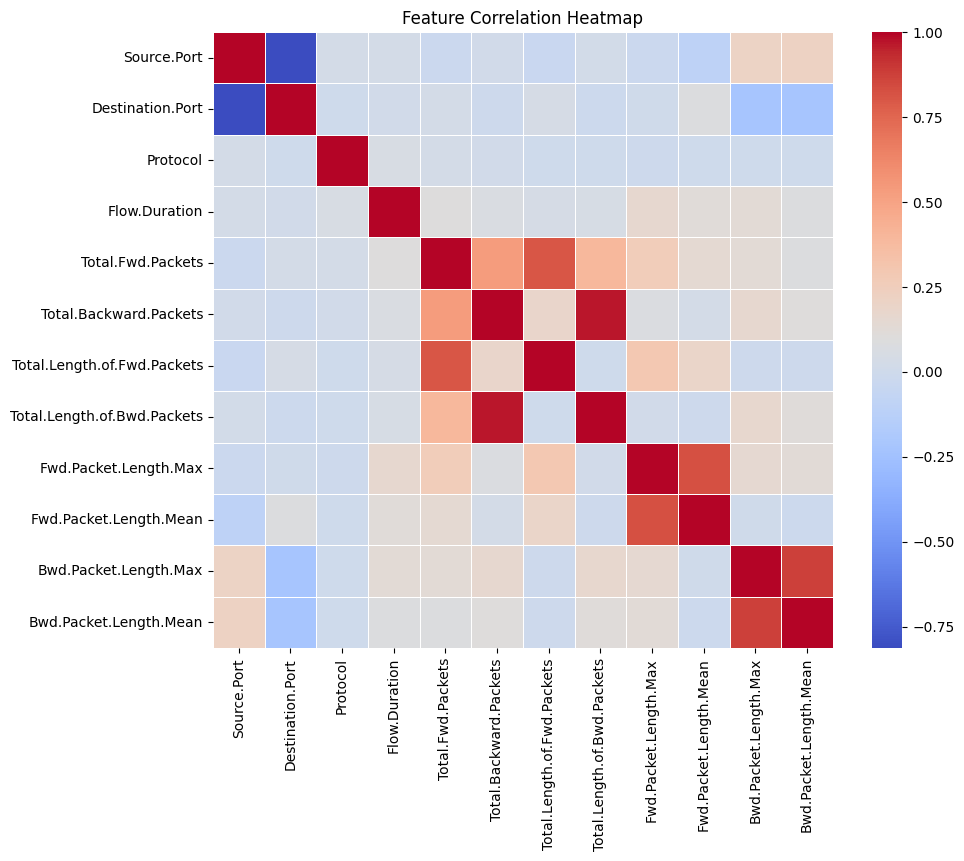

In [ ]:
# Cell: EDA - Correlation Matrix
plt.figure(figsize=(10, 8))

# Select only numeric columns for correlation
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])

# Compute correlation
corr = numeric_df.corr()

# Draw Heatmap
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (320000, 12)
Testing Data: (80000, 12)


In [ ]:
# 1. n_estimators=100 (Smarter brain, takes 20 seconds longer to train)
# 2. class_weight='balanced' (Fixes the issue where AI ignores rare apps)
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

print("🚀 Training Optimzed AI Model... (This may take 1-2 minutes)")
clf.fit(X_train, y_train)

print("✅ Training Complete!")

🚀 Training Optimzed AI Model... (This may take 1-2 minutes)
✅ Training Complete!


In [ ]:
# Initialize the Model
clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("🚀 Training AI Model... (This takes about 30-60 seconds)")
clf.fit(X_train, y_train)

print("✅ Training Complete! The AI has learned to recognize traffic.")

🚀 Training AI Model... (This takes about 30-60 seconds)
✅ Training Complete! The AI has learned to recognize traffic.


In [ ]:
!pip install xgboost

XGBOOOST

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib
import os
from google.colab import drive
from google.colab import files

# 1. Load Data
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/SDWAN_Project/Dataset-Unicauca-Version2-87Atts.csv'

print("⏳ Loading Data...")
df = pd.read_csv(file_path, nrows=200000)

# 2. Group Labels
def map_category(app_name):
    name = str(app_name).upper()
    if 'YOUTUBE' in name or 'NETFLIX' in name or 'TWITCH' in name: return 'Streaming'
    elif 'SKYPE' in name or 'WHATSAPP' in name or 'VOIP' in name: return 'VoIP_Call'
    elif 'GMAIL' in name or 'OUTLOOK' in name or 'WEB' in name: return 'Web_Browsing'
    else: return 'Web_Browsing' # Default everything else to Web

if 'ProtocolName' in df.columns: target = 'ProtocolName'
else: target = df.columns[-1]

df[target] = df[target].apply(map_category)

# --- 3. THE FIX: SELECT ONLY 4 STRONG FEATURES ---
# We ignore the complex statistical features.
features = ['Protocol', 'Flow.Duration', 'Total.Length.of.Fwd.Packets', 'Destination.Port']

# Clean Data
df = df[features + [target]].dropna()

# 4. Train
X = df[features]
y = df[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"🎯 Classes to Learn: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=50)
model.fit(X_train, y_train)
print("✅ Training Complete.")

# 5. Save & Download
joblib.dump(model, 'traffic_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
files.download('traffic_model.pkl')
files.download('label_encoder.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Loading Data...
🎯 Classes to Learn: ['Streaming' 'VoIP_Call' 'Web_Browsing']
✅ Training Complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time
import random
from IPython.display import clear_output, display
import sys

# --- 1. Fix the Data Format (Crucial Step) ---
# We convert the DataFrame to a simple Numpy Array to avoid KeyError
X_test_numpy = X_test.values

# --- 2. Define Visual Logic ---

def get_emoji(category):
    if category == "Streaming": return "🎬 VIDEO"
    if category == "VoIP_Call": return "📞 VOIP"
    if category == "Social_Media": return "📱 SOCIAL"
    if category == "Web_Browsing": return "🌐 WEB"
    if category == "P2P_Transfer": return "⬇️ P2P"
    if category == "Email": return "📧 MAIL"
    return "📁 DATA"

def get_route(category):
    # SD-WAN LOGIC
    # Critical = MPLS
    if category == "VoIP_Call" or category == "Email":
        return "⚡ MPLS (VIP PATH)"
    # Bulk/Entertainment = Internet
    elif category == "Streaming" or category == "P2P_Transfer" or category == "Social_Media":
        return "🛣️ BROADBAND (Cheap)"
    # Default
    else:
        return "🛣️ BROADBAND (Cheap)"

# --- 3. Prepare Simulation Data ---
# Map predictions to array indices so we can force specific traffic types
indices_by_cat = {}
print("⚙️ Pre-calculating simulation data...")

# Predict on all test data first
preds_all = model.predict(X_test)

# Group indices by what the model thinks they are
for i, label_idx in enumerate(preds_all):
    # Get the name (e.g., "Streaming")
    # Handle both LabelEncoder output or raw strings
    if hasattr(le, 'inverse_transform'):
        label_name = le.inverse_transform([label_idx])[0]
    else:
        label_name = label_idx # If you used a different method

    if label_name not in indices_by_cat:
        indices_by_cat[label_name] = []
    indices_by_cat[label_name].append(i)

# --- 4. Run Live Simulation ---
mpls_load = 10
internet_load = 10
history = []

try:
    print("🚀 STARTING AI SD-WAN CONTROLLER SIMULATION...")
    time.sleep(1)

    # Run for 20 loops
    for i in range(1, 21):

        # A. Force variety (Cycle through types)
        forced_types = ['Web_Browsing', 'Streaming', 'Web_Browsing', 'VoIP_Call', 'Social_Media']
        target_type = forced_types[i % len(forced_types)]

        # B. Pick a real random data point of that type
        # We use the numpy array 'X_test_numpy' which fixes the KeyError
        if target_type in indices_by_cat and len(indices_by_cat[target_type]) > 0:
            idx = random.choice(indices_by_cat[target_type])
            packet_data = X_test_numpy[idx].reshape(1, -1)
        else:
            # Fallback
            idx = random.randint(0, len(X_test_numpy)-1)
            packet_data = X_test_numpy[idx].reshape(1, -1)

        # C. AI Prediction
        pred_idx = model.predict(packet_data)[0]
        app_name = le.inverse_transform([pred_idx])[0]

        # D. SD-WAN Decision
        route = get_route(app_name)

        # E. Update Load Bars
        if "MPLS" in route:
            mpls_load += random.randint(5, 15)
            internet_load -= random.randint(1, 5)
            color = "\033[92m" # Green Text
        else:
            internet_load += random.randint(5, 15)
            mpls_load -= random.randint(1, 5)
            color = "\033[94m" # Blue Text

        emoji_label = get_emoji(app_name)

        # Clamp values between 0 and 100
        mpls_load = max(5, min(100, mpls_load))
        internet_load = max(5, min(100, internet_load))

        # --- F. VISUALIZATION ---
        clear_output(wait=True)

        print(f"📡 PACKET #{i} DETECTED...\n")

        print("--------------------------------------------------")
        print(f"🔎 AI CLASSIFICATION : {emoji_label} ({app_name})")
        print(f"🔀 SD-WAN ROUTING    : {color}{route}\033[0m")
        print("--------------------------------------------------")
        print("\n📊 LIVE LINK UTILIZATION:")

        # Dynamic ASCII Bars
        bar_len = 20
        mpls_filled = int((mpls_load / 100) * bar_len)
        net_filled = int((internet_load / 100) * bar_len)

        print(f"MPLS (Secure): [{'█' * mpls_filled}{'░' * (bar_len - mpls_filled)}] {mpls_load}%")
        print(f"NET  (Public): [{'█' * net_filled}{'░' * (bar_len - net_filled)}] {internet_load}%")

        print("\n📜 DECISION LOG:")
        history.insert(0, f"#{i} {emoji_label} -> {route}")
        for log in history[:5]: # Show last 5
            print(log)

        time.sleep(2) # Speed of simulation

    print("\n✅ SIMULATION COMPLETE.")

except KeyboardInterrupt:
    print("\n🛑 Simulation Stopped.")

📡 PACKET #20 DETECTED...

--------------------------------------------------
🔎 AI CLASSIFICATION : 🌐 WEB (Web_Browsing)
🔀 SD-WAN ROUTING    : 🛣️ BROADBAND (Cheap)
--------------------------------------------------

📊 LIVE LINK UTILIZATION:
MPLS (Secure): [██░░░░░░░░░░░░░░░░░░] 13%
NET  (Public): [████████████████████] 100%

📜 DECISION LOG:
#20 🌐 WEB -> 🛣️ BROADBAND (Cheap)
#19 📱 SOCIAL -> 🛣️ BROADBAND (Cheap)
#18 📞 VOIP -> ⚡ MPLS (VIP PATH)
#17 🌐 WEB -> 🛣️ BROADBAND (Cheap)
#16 🎬 VIDEO -> 🛣️ BROADBAND (Cheap)

✅ SIMULATION COMPLETE.


# New Section